In [225]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy import stats
from arch import arch_model


In [226]:
DATA_PATH = r"C:\Programming\ETH\SS26\ISQT26\final\playground\market_data.xlsx"
DATA_SHEET = "US"
LEGEND_SHEET = "legend"
TARGET_COL = "_MKT"

TEST_YEARS = 5
HORIZON = 1
VOL_WINDOW = 4
VOL_ANNUALIZE = False
WEEKS_PER_YEAR = 52

RETURN_SCALE = 1.0
EPS = 1e-10
OPT_MAXITER = 5000
HIT_THRESHOLD_MODE = "train_mean"

In [227]:
df = pd.read_excel(DATA_PATH, sheet_name=DATA_SHEET, engine="openpyxl", index_col=0)
namings = pd.read_excel(DATA_PATH, sheet_name=LEGEND_SHEET, engine="openpyxl", index_col=0)

df.index = pd.to_datetime(df.index)
df = df.sort_index()

df.head()

,EMP,PE,CAPE,DY,Rho,MOV,IR,RR,Y02,Y10,...,YSS,NYF,_AU,_DXY,_LCP,_TY,_OIL,_MKT,_VA,_GR
Date,,,,,,,,,,,,,,,,,,,,,
1988-04-10,0.019766,12.9,14.469,3.60,-0.083,118.0,6.02,-1.061,7.459,8.484,...,0.251622,6.896895,450.50,89.14,2473.7,97.990,16.87,419.06,823.219,462.551
1988-04-17,0.019766,12.4,13.960,3.75,-0.078,121.0,5.88,-0.760,7.582,8.737,...,0.328976,2.631749,456.25,88.31,2328.2,96.534,18.32,404.66,823.219,462.551
1988-04-24,0.019766,12.4,13.950,3.75,-0.051,123.0,5.83,-0.760,7.618,8.773,...,0.156475,2.631749,449.25,88.89,2201.4,96.470,18.13,404.71,823.219,462.551
1988-05-01,0.019602,12.5,14.036,3.75,-0.054,124.2,5.98,-0.760,7.728,8.873,...,0.146747,2.631749,449.00,89.16,2147.8,96.005,18.10,407.55,840.891,461.176
1988-05-08,0.019785,12.3,13.761,3.82,-0.079,118.4,6.29,-0.760,7.885,8.990,...,0.147628,2.631749,443.00,89.30,2200.9,95.446,17.63,401.29,840.891,461.176


In [228]:
def log_returns(price):
    return np.log(price / price.shift(1)).dropna()


def future_realized_vol_from_returns(
    returns,
    horizon=1,
    window=4,
    annualize=False,
    weeks_per_year=52,
):
    scale = np.sqrt(weeks_per_year) if annualize else 1.0

    y = pd.Series(index=returns.index, dtype=float)
    y_end_date = pd.Series(index=returns.index, dtype="datetime64[ns]")

    for t in range(len(returns)):
        start = t + horizon
        end = start + window

        if end <= len(returns):
            rr = returns.iloc[start:end]

            if rr.notna().all():
                y.iloc[t] = np.sqrt(np.mean(rr.values ** 2)) * scale
                y_end_date.iloc[t] = returns.index[end - 1]

    return pd.DataFrame({
        "actual_vol": y,
        "y_end_date": y_end_date,
    }).dropna()


def fit_garch11_arch_package(returns_scaled, split_date):
    model = arch_model(
        returns_scaled,
        mean="Constant",
        vol="GARCH",
        p=1,
        o=1,
        q=1,
        dist="studentst",
        rescale=False,
    )

    res = model.fit(
        last_obs=split_date,
        disp="off",
        show_warning=False,
    )

    return res


def forecast_window_vol_arch_package(
    res,
    horizon=1,
    window=4,
    annualize=False,
    weeks_per_year=52,
    return_scale=100.0,
    start=None,
):
    forecast_horizon = horizon + window - 1

    fc = res.forecast(
        horizon=forecast_horizon,
        start=start,
        align="origin",
        reindex=True,
    )

    variance = fc.variance

    start_col = horizon - 1
    end_col = horizon - 1 + window

    pred_var_scaled = variance.iloc[:, start_col:end_col].mean(axis=1)
    pred_vol = np.sqrt(pred_var_scaled) / return_scale

    if annualize:
        pred_vol *= np.sqrt(weeks_per_year)

    pred_vol.name = "predicted_vol"

    return pred_vol.dropna()


def hit_ratio(actual, predicted, threshold):
    return np.mean((actual > threshold) == (predicted > threshold))


def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))


def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

In [229]:
price = df["_MKT"].dropna()

returns = log_returns(price)
returns_scaled = returns * 100.0

split_date = price.index.max() - pd.DateOffset(years=TEST_YEARS)

actual = future_realized_vol_from_returns(
    returns,
    horizon=HORIZON,
    window=VOL_WINDOW,
    annualize=VOL_ANNUALIZE,
    weeks_per_year=WEEKS_PER_YEAR,
)

garch_res = fit_garch11_arch_package(
    returns_scaled,
    split_date=split_date,
)

predicted_vol = forecast_window_vol_arch_package(
    garch_res,
    horizon=HORIZON,
    window=VOL_WINDOW,
    annualize=VOL_ANNUALIZE,
    weeks_per_year=WEEKS_PER_YEAR,
    return_scale=100.0,
    start=actual.index.min(),
)

eval_data = actual.join(predicted_vol, how="inner")

train_eval = eval_data.loc[eval_data.index < split_date].copy()
test_eval = eval_data.loc[eval_data.index >= split_date].copy()

threshold = train_eval["actual_vol"].mean()

metrics = pd.DataFrame({
    "train": {
        "hit": hit_ratio(train_eval["actual_vol"], train_eval["predicted_vol"], threshold),
        "rmse": rmse(train_eval["actual_vol"], train_eval["predicted_vol"]),
        "mae": mae(train_eval["actual_vol"], train_eval["predicted_vol"]),
    },
    "test": {
        "hit": hit_ratio(test_eval["actual_vol"], test_eval["predicted_vol"], threshold),
        "rmse": rmse(test_eval["actual_vol"], test_eval["predicted_vol"]),
        "mae": mae(test_eval["actual_vol"], test_eval["predicted_vol"]),
    },
}).T

display(garch_res.summary())
display(metrics)
display(eval_data.tail())

<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - GJR-GARCH Model Results                       
====================================================================================
Dep. Variable:                         _MKT   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -3560.89
Distribution:      Standardized Student's t   AIC:                           7133.78
Method:                  Maximum Likelihood   BIC:                           7166.50
                                              No. Observations:                 1725
Date:                      Thu, Jun 18 2026   Df Residuals:                     1724
Time:                              13:35:26   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.2785  4.081e-02      6.825  8.805e-12 [  0.199,  0.359]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.3187  9.683e-02      3.291  9.986e-04      [  0.129,  0.508]
alpha[1]       0.0273  2.501e-02      1.090      0.276 [-2.176e-02,7.629e-02]
gamma[1]       0.2754  6.583e-02      4.184  2.870e-05      [  0.146,  0.404]
beta[1]        0.7616  5.165e-02     14.746  3.281e-49      [  0.660,  0.863]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             7.5637      1.456      5.196  2.040e-07 [  4.710, 10.417]
========================================================================

Covariance estimator: robust
"""

,hit,rmse,mae
train,0.70029,0.011197,0.007495
test,0.70428,0.009009,0.006896


,actual_vol,y_end_date,predicted_vol
Date,,,
2026-03-08,0.023067,2026-04-05,0.019345
2026-03-15,0.027350,2026-04-12,0.020514
2026-03-22,0.034339,2026-04-19,0.022148
2026-03-29,0.032960,2026-04-26,0.023454
2026-04-05,0.028802,2026-05-03,0.021935


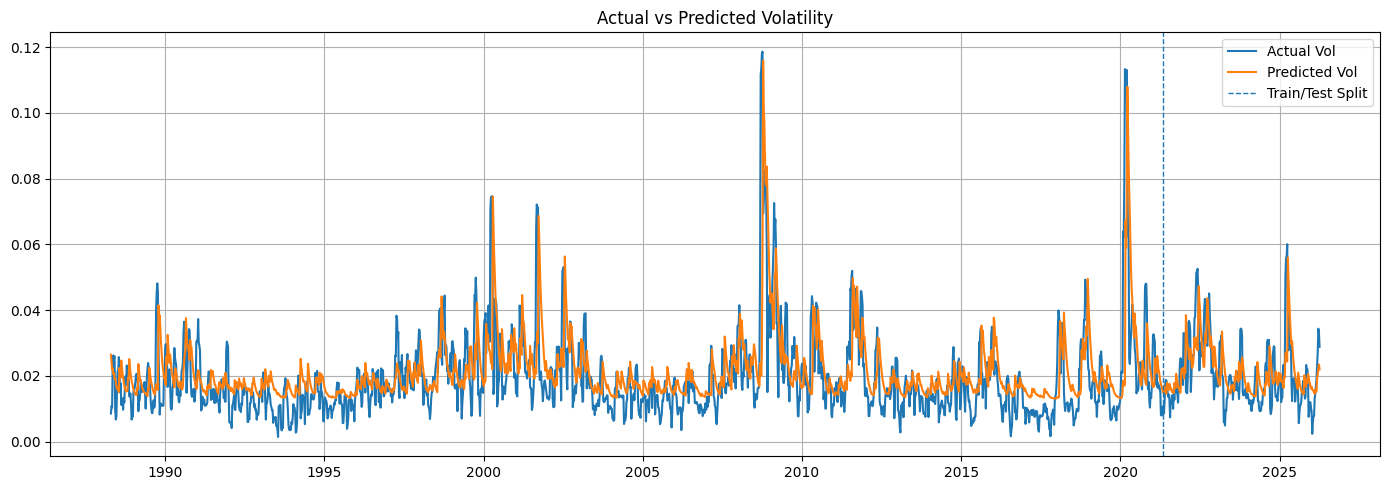

In [230]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(eval_data.index, eval_data["actual_vol"], label="Actual Vol")
ax.plot(eval_data.index, eval_data["predicted_vol"], label="Predicted Vol")
ax.axvline(split_date, linewidth=1, linestyle="--", label="Train/Test Split")
ax.set_title("Actual vs Predicted Volatility")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

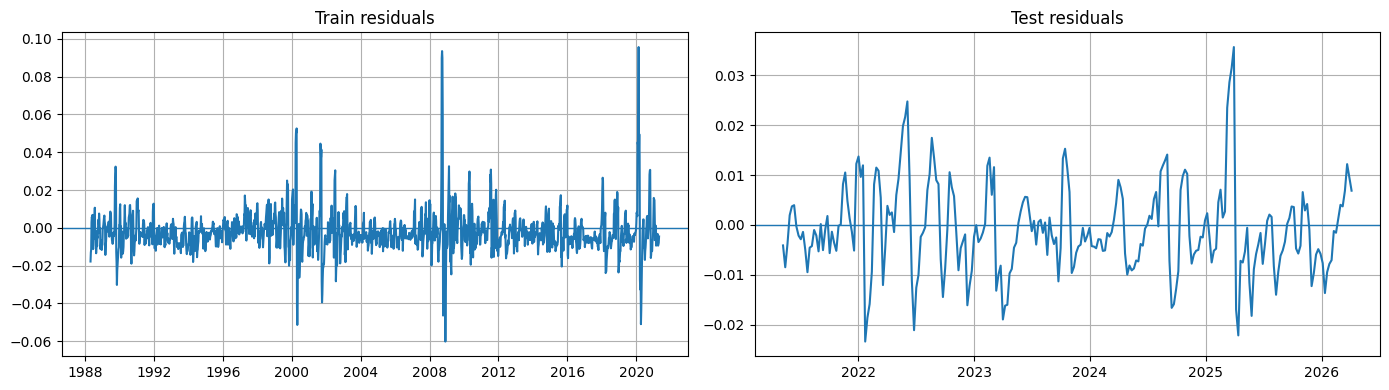

In [231]:
eval_data["residual"] = eval_data["actual_vol"] - eval_data["predicted_vol"]

train_resid = eval_data.loc[eval_data.index < split_date, "residual"].dropna()
test_resid = eval_data.loc[eval_data.index >= split_date, "residual"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_resid.index, train_resid)
axes[0].axhline(0.0, linewidth=1)
axes[0].set_title("Train residuals")
axes[0].grid(True)

axes[1].plot(test_resid.index, test_resid)
axes[1].axhline(0.0, linewidth=1)
axes[1].set_title("Test residuals")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [232]:
eval_data["residual"] = eval_data["actual_vol"] - eval_data["predicted_vol"]

train_eval = eval_data.loc[eval_data.index < split_date].copy()
test_eval = eval_data.loc[eval_data.index >= split_date].copy()

train_resid = train_eval["residual"].dropna()
test_resid = test_eval["residual"].dropna()

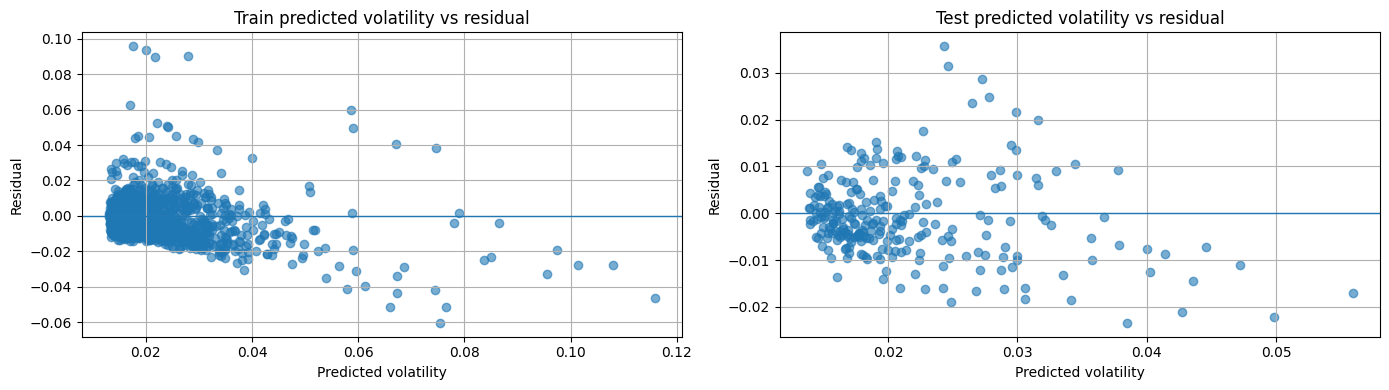

In [233]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(train_eval["predicted_vol"], train_eval["residual"], alpha=0.6)
axes[0].axhline(0.0, linewidth=1)
axes[0].set_title("Train predicted volatility vs residual")
axes[0].set_xlabel("Predicted volatility")
axes[0].set_ylabel("Residual")
axes[0].grid(True)

axes[1].scatter(test_eval["predicted_vol"], test_eval["residual"], alpha=0.6)
axes[1].axhline(0.0, linewidth=1)
axes[1].set_title("Test predicted volatility vs residual")
axes[1].set_xlabel("Predicted volatility")
axes[1].set_ylabel("Residual")
axes[1].grid(True)

plt.tight_layout()
plt.show()

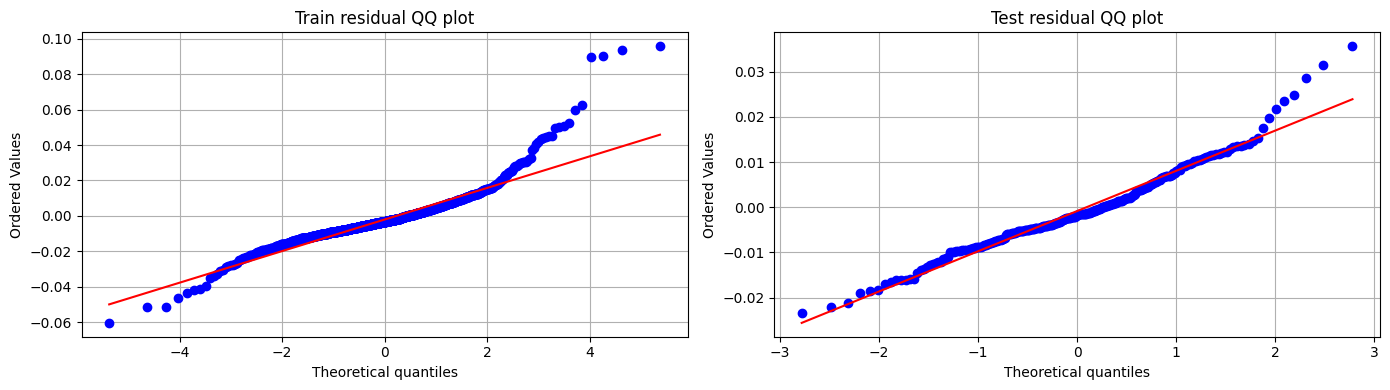

In [234]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

nu = garch_res.params["nu"]

stats.probplot(
    train_resid,
    dist=stats.t,
    sparams=(nu,),
    plot=axes[0],
)
# stats.probplot(train_resid, dist="student_t", plot=axes[0])
axes[0].set_title("Train residual QQ plot")
axes[0].grid(True)

stats.probplot(test_resid, dist="norm", plot=axes[1])
axes[1].set_title("Test residual QQ plot")
axes[1].grid(True)

plt.tight_layout()
plt.show()

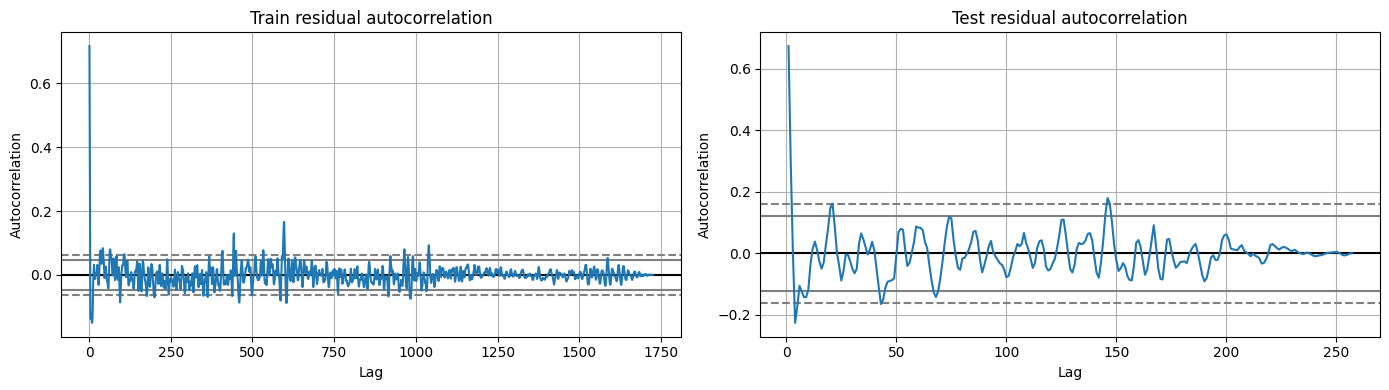

In [235]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pd.plotting.autocorrelation_plot(train_resid, ax=axes[0])
axes[0].set_title("Train residual autocorrelation")
axes[0].grid(True)

pd.plotting.autocorrelation_plot(test_resid, ax=axes[1])
axes[1].set_title("Test residual autocorrelation")
axes[1].grid(True)

plt.tight_layout()
plt.show()

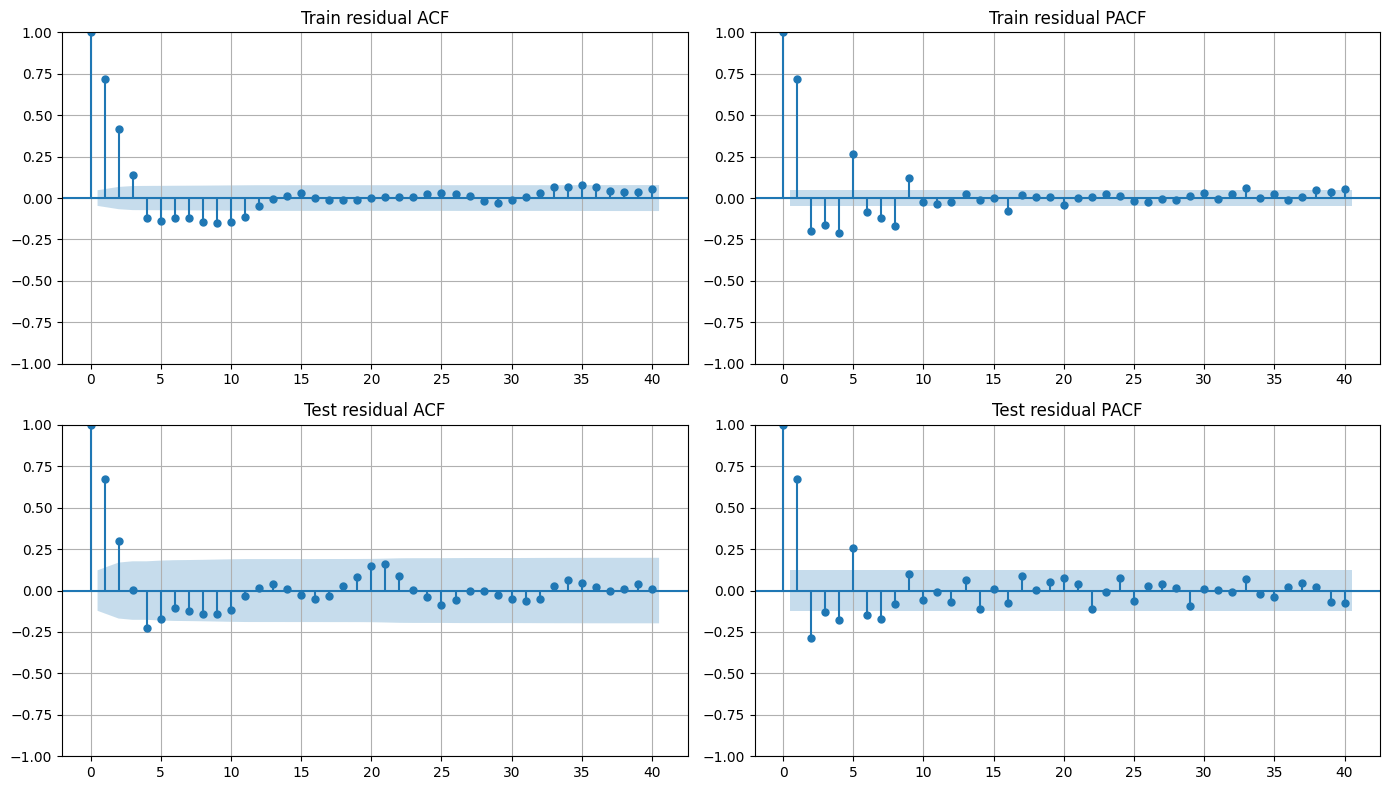

In [236]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

PACF_LAGS = 40

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(train_resid, lags=PACF_LAGS, ax=axes[0, 0])
axes[0, 0].set_title("Train residual ACF")
axes[0, 0].grid(True)

plot_pacf(train_resid, lags=PACF_LAGS, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("Train residual PACF")
axes[0, 1].grid(True)

plot_acf(test_resid, lags=min(PACF_LAGS, len(test_resid) // 2 - 1), ax=axes[1, 0])
axes[1, 0].set_title("Test residual ACF")
axes[1, 0].grid(True)

plot_pacf(
    test_resid,
    lags=min(PACF_LAGS, len(test_resid) // 2 - 1),
    ax=axes[1, 1],
    method="ywm",
)
axes[1, 1].set_title("Test residual PACF")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [299]:
VOL_RANK_WINDOW = 52
HIGH_VOL_RANK = 0.95
LOW_VOL_RANK = 0.05
TRADE_SIZE = 0.01
MIN_SHARES = -1
MAX_SHARES = 2

price = df["_MKT"].dropna()

bt = eval_data[["predicted_vol"]].join(price.rename("price"), how="inner").dropna()

bt["vol_rank_52"] = (
    bt["predicted_vol"]
    .rolling(VOL_RANK_WINDOW)
    .rank(pct=True)
)

cash = 0.0
shares = 1.0

cash_path = []
shares_path = []
strategy_value_path = []
baseline_value_path = []
signal_path = []
trade_path = []

for date, row in bt.iterrows():
    p = row["price"]
    vol_rank = row["vol_rank_52"]

    trade = 0.0
    signal = 0.0

    if pd.notna(vol_rank):
        if vol_rank > HIGH_VOL_RANK:
            trade = -min(TRADE_SIZE, shares - MIN_SHARES)
            signal = -1.0
        elif vol_rank < LOW_VOL_RANK:
            trade = min(TRADE_SIZE, MAX_SHARES - shares)
            signal = 1.0

    cash -= trade * p
    shares += trade

    cash_path.append(cash)
    shares_path.append(shares)
    trade_path.append(trade)
    signal_path.append(signal)
    strategy_value_path.append(cash + shares * p)
    baseline_value_path.append(p)

bt["cash"] = cash_path
bt["shares"] = shares_path
bt["trade"] = trade_path
bt["signal"] = signal_path
bt["strategy_value"] = strategy_value_path
bt["baseline_value"] = baseline_value_path

bt["strategy_return"] = bt["strategy_value"] / bt["strategy_value"].iloc[0] - 1.0
bt["baseline_return"] = bt["baseline_value"] / bt["baseline_value"].iloc[0] - 1.0
bt["active_return"] = bt["strategy_return"] - bt["baseline_return"]

bt["strategy_period_return"] = bt["strategy_value"].pct_change()
bt["baseline_period_return"] = bt["baseline_value"].pct_change()
bt["active_period_return"] = bt["strategy_period_return"] - bt["baseline_period_return"]

strategy_sr = (
    bt["strategy_period_return"].mean()
    / bt["strategy_period_return"].std()
    * np.sqrt(52)
    if bt["strategy_period_return"].std() > 0 else np.nan
)

baseline_sr = (
    bt["baseline_period_return"].mean()
    / bt["baseline_period_return"].std()
    * np.sqrt(52)
    if bt["baseline_period_return"].std() > 0 else np.nan
)

active_sr = (
    bt["active_period_return"].mean()
    / bt["active_period_return"].std()
    * np.sqrt(52)
    if bt["active_period_return"].std() > 0 else np.nan
)

trades = bt["trade"].abs().fillna(0.0)

strategy_metrics = pd.Series({
    "final_strategy_value": bt["strategy_value"].iloc[-1],
    "final_baseline_value": bt["baseline_value"].iloc[-1],
    "strategy_return": bt["strategy_return"].iloc[-1],
    "baseline_return": bt["baseline_return"].iloc[-1],
    "active_return": bt["active_return"].iloc[-1],
    "strategy_sr": strategy_sr,
    "baseline_sr": baseline_sr,
    "active_sr": active_sr,
    "mean_shares": bt["shares"].mean(),
    "min_shares": bt["shares"].min(),
    "max_shares": bt["shares"].max(),
    "number_of_trades": (trades > 0).sum(),
    "total_turnover_units": trades.sum(),
})

display(strategy_metrics)
display(bt.tail())

final_strategy_value    34219.544500
final_baseline_value    26446.110000
strategy_return            83.563694
baseline_return            64.353902
active_return              19.209792
strategy_sr                 0.775516
baseline_sr                 0.751950
active_sr                   0.449920
mean_shares                 1.152528
min_shares                  0.900000
max_shares                  1.510000
number_of_trades          299.000000
total_turnover_units        2.990000
dtype: float64

,predicted_vol,price,vol_rank_52,cash,shares,trade,signal,strategy_value,baseline_value,strategy_return,baseline_return,active_return,strategy_period_return,baseline_period_return,active_period_return
Date,,,,,,,,,,,,,,,
2026-03-08,0.019345,27023.67,0.596154,-5714.0816,1.51,0.0,0.0,35091.6601,27023.67,85.718875,65.781174,19.937701,-0.024616,-0.021242,-0.003374
2026-03-15,0.020514,26592.55,0.692308,-5714.0816,1.51,0.0,0.0,34440.6689,26592.55,84.110139,64.715786,19.394353,-0.018551,-0.015953,-0.002598
2026-03-22,0.022148,26087.44,0.769231,-5714.0816,1.51,0.0,0.0,33677.9528,26087.44,82.225307,63.467553,18.757754,-0.022146,-0.018994,-0.003151
2026-03-29,0.023454,25578.24,0.807692,-5714.0816,1.51,0.0,0.0,32909.0608,25578.24,80.325213,62.209213,18.116001,-0.022831,-0.019519,-0.003312
2026-04-05,0.021935,26446.11,0.769231,-5714.0816,1.51,0.0,0.0,34219.5445,26446.11,83.563694,64.353902,19.209792,0.039821,0.033930,0.005891


In [300]:
def constant_share_value(price, shares):
    p0 = price.iloc[0]
    initial_value = p0
    cash = initial_value - shares * p0
    return cash + shares * price


def period_return(value):
    return value.pct_change()


def total_return(value):
    return value.iloc[-1] / value.iloc[0] - 1.0


def ann_sharpe_from_returns(r, periods_per_year=52):
    r = r.dropna()
    if r.std() == 0 or len(r) == 0:
        return np.nan
    return r.mean() / r.std() * np.sqrt(periods_per_year)


def ann_ir(value, benchmark, periods_per_year=52):
    r = period_return(value)
    b = period_return(benchmark)
    active = (r - b).dropna()
    if active.std() == 0 or len(active) == 0:
        return np.nan
    return active.mean() / active.std() * np.sqrt(periods_per_year)


def max_drawdown(value):
    wealth = value / value.iloc[0]
    dd = wealth / wealth.cummax() - 1.0
    return dd.min()


mean_shares = bt["shares"].mean()

bt["constant_1x_value"] = constant_share_value(bt["price"], 1.0)
bt["constant_2x_value"] = constant_share_value(bt["price"], 2.0)
bt["constant_mean_shares_value"] = constant_share_value(bt["price"], mean_shares)

value_cols = {
    "strategy": "strategy_value",
    "constant_1x": "constant_1x_value",
    "constant_2x": "constant_2x_value",
    "constant_mean_shares": "constant_mean_shares_value",
}

benchmark_col = "constant_1x_value"

comparison = {}

for name, col in value_cols.items():
    r = period_return(bt[col])
    b = period_return(bt[benchmark_col])
    active = r - b

    comparison[name] = {
        "final_value": bt[col].iloc[-1],
        "total_return": total_return(bt[col]),
        "annual_sharpe": ann_sharpe_from_returns(r),
        "annual_ir_vs_1x": ann_sharpe_from_returns(active),
        "max_drawdown": max_drawdown(bt[col]),
    }

comparison["strategy"].update({
    "mean_shares": bt["shares"].mean(),
    "min_shares": bt["shares"].min(),
    "max_shares": bt["shares"].max(),
    "number_of_trades": (bt["trade"].abs() > 1e-12).sum(),
    "total_turnover_units": bt["trade"].abs().sum(),
})

comparison["constant_1x"].update({
    "mean_shares": 1.0,
    "min_shares": 1.0,
    "max_shares": 1.0,
    "number_of_trades": 0.0,
    "total_turnover_units": 0.0,
})

comparison["constant_2x"].update({
    "mean_shares": 2.0,
    "min_shares": 2.0,
    "max_shares": 2.0,
    "number_of_trades": 0.0,
    "total_turnover_units": 0.0,
})

comparison["constant_mean_shares"].update({
    "mean_shares": mean_shares,
    "min_shares": mean_shares,
    "max_shares": mean_shares,
    "number_of_trades": 0.0,
    "total_turnover_units": 0.0,
})

comparison = pd.DataFrame(comparison).T

display(comparison)

,final_value,total_return,annual_sharpe,annual_ir_vs_1x,max_drawdown,mean_shares,min_shares,max_shares,number_of_trades,total_turnover_units
strategy,34219.544500,83.563694,0.775516,0.449920,-0.527725,1.152528,0.900000,1.510000,299.0,2.99
constant_1x,26446.110000,64.353902,0.751950,NaN,-0.536168,1.000000,1.000000,1.000000,0.0,0.00
constant_2x,52487.560000,128.707804,0.794521,0.712822,-0.560928,2.000000,2.000000,2.000000,0.0,0.00
constant_mean_shares,30418.153769,74.169658,0.761391,0.759504,-0.542506,1.152528,1.152528,1.152528,0.0,0.00


In [301]:
returns_by_model = pd.DataFrame(index=bt.index)

returns_by_model["mkt"] = period_return(bt["constant_1x_value"])
returns_by_model["strategy"] = period_return(bt["strategy_value"])
returns_by_model["constant_2x"] = period_return(bt["constant_2x_value"])
returns_by_model["constant_mean_shares"] = period_return(bt["constant_mean_shares_value"])

annual_rows = []

for year, g in returns_by_model.groupby(returns_by_model.index.year):
    row = {
        "year": year,
        "sample": "test" if g.index.max() >= split_date else "train",
    }

    r_mkt = g["mkt"]

    for name in ["strategy", "constant_2x", "constant_mean_shares"]:
        active = (g[name] - r_mkt).dropna()

        row[f"{name}_IR"] = (
            active.mean() / active.std() * np.sqrt(52)
            if active.std() > 0 and len(active) > 0
            else np.nan
        )

        row[f"{name}_active_return"] = (
            (1.0 + active).prod() - 1.0
            if len(active) > 0
            else np.nan
        )

    annual_rows.append(row)

annual_ir = pd.DataFrame(annual_rows).set_index(["year", "sample"])

display(annual_ir)

,,strategy_IR,strategy_active_return,constant_2x_IR,constant_2x_active_return,constant_mean_shares_IR,constant_mean_shares_active_return
year,sample,,,,,,
1988,train,NaN,0.000000,1.235686,0.097803,1.200318,0.014859
1989,train,0.725698,0.002122,2.531864,0.228377,2.440076,0.037247
1990,train,-0.967483,-0.001112,0.264783,0.019649,0.231179,0.003696
1991,train,1.330355,0.007770,2.268436,0.137494,2.276934,0.026427
1992,train,1.398993,0.006818,1.381359,0.039891,1.380516,0.008459
1993,train,0.666900,0.005385,0.798764,0.019631,0.793216,0.004284
1994,train,0.194660,0.001507,0.378798,0.009617,0.369327,0.002127
1995,train,4.320409,0.047162,4.842579,0.073223,4.830509,0.016300
1996,train,1.619454,0.016267,2.000963,0.038920,1.999851,0.009134
